# QNN(Quantum Neural Network)
QNN combina un circuito cuántico parametrizado con capas clásicas. El núcleo es el circuito cuántico variacional (VQC):
1. Encoding - los datos clásicos (retornos) se codifican en qubits mediante rotaciones angulares (RX, RY)
2. Capas variacionales - puertas cuánticas parametrizadas (RX, RY, RZ) + entrelazamiento (CNOT) que el modelo aprende a optimizar
3. Medición - se mide el valor esperado de cada qubit, produciendo un output clásico
4. Capa clásica - una capa lineal final convierte el output cuántico en la predicción.

Arquitectura: 
* 4 qubits
* 2 Capas variacionales
* Simulador cuántico de Pennylane
* Capa clásica de salida

# Importaciones y configuraciones

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pennylane as qml
import warnings
warnings.filterwarnings("ignore")

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Paths
DATA_PATH = Path.cwd().parent / "data"
RESULTS_PATH = Path.cwd().parent / "results"

# Activos
ACTIVOS = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]

# Configuración cuántica
N_QUBITS = 6
N_LAYERS = 2

print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Dispositivo cuántico: default.qubit ({N_QUBITS} qubits, {N_LAYERS} capas)")
print("\nDatos disponibles:")
for a in ACTIVOS:
    df = pd.read_csv(DATA_PATH / f"{a}_processed.csv", index_col=0)
    print(f" {a.upper()}: {len(df)} filas")

PennyLane version: 0.44.1
PyTorch version: 2.10.0+cpu
Dispositivo cuántico: default.qubit (6 qubits, 2 capas)

Datos disponibles:
 EURUSD: 2134 filas
 GBPUSD: 2134 filas
 USDJPY: 2135 filas
 BTC: 2995 filas
 ETH: 2995 filas


# Arquitectura QNN

In [13]:
# -- Dispositivo  cuántico ------------------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

# -- Circuito cuántico variacional ----------------------------
@qml.qnode(dev, interface="torch")
def circuito_cuantico(inputs, weights):
    # Encoding: codificar los primeros N_QUBITS valores de la secuencia
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
        
    # Capas variacionales
    for layer in range(N_LAYERS):
        # Rotaciones parametrizadas
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
        # Entrelazamiento
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS -1, 0])    # circular
        
    # Medición: valor esperado de cada qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# -- Modelo QNN híbrido ---------------------------------------
class QNNModel(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=N_LAYERS):
        super(QNNModel, self).__init__()
        # Pesos del circuito cuántico: [n_layers, n_qubits, 3 rotaciones]
        self.weights = nn.Parameter(
            torch.randn(n_layers, n_qubits, 3) * 0.1
        )
        # Capa clásica de reducción de features
        self.fc_in = nn.Linear(20, n_qubits)    # window=20 --> n_qubits
        # Capa clásica de salida
        self.fc_out = nn.Linear(n_qubits, 1)
        
    def forward(self, x):
        # x: [batch, window, 1] -> [batch, window]
        x = x.squeeze(-1)
        
        # Reducción clásica: window -> n_qubits
        x = torch.tanh(self.fc_in(x))   # tanh para mantener rango [-1, 1]
        
        # Circuito cuántico para cada elemento del batch
        q_out = torch.stack([
            torch.stack(circuito_cuantico(x[i], self.weights))
            for i in range(x.shape[0])
        ]).float()
        
        # Capa clásica de salida
        return self.fc_out(q_out)
    
# -- Función: crear secuencias --------------------------------
def crear_secuencias(serie, window=20):
    X, y = [], []
    for i in range(len(serie) - window):
        X.append(serie[i:i+window])
        y.append(serie[i+window])
    return np.array(X), np.array(y)

# -- Función: entrenar y evaluar un activo --------------------
def entrenar_qnn(nombre, window=20, epochs=50, batch_size=32):
    # Cargar datos 
    df = pd.read_csv(DATA_PATH / f"{nombre}_processed.csv", index_col=0, parse_dates=True)
    retornos = df["Retorno"].dropna().values.reshape(-1, 1)
    regimen = df["Regimen"].dropna().values
    
    # Escalar
    scaler = StandardScaler()
    retornos_scaled = scaler.fit_transform(retornos).flatten()
    
    # Secuencias
    X, y = crear_secuencias(retornos_scaled, window)
    
    # Split 80/20 temporal
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Alinear régimen
    regimen_y = regimen[window:]
    reg_test = regimen_y[split:split + len(y_test)]
    
    # Tensores
    X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(-1)
    X_test_tensor = torch.FloatTensor(X_test).unsqueeze(-1)
    
    # DataLoader
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo 
    model = QNNModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f" {nombre.upper()} epoch {epoch+1}/{epochs} - loss: {epoch_loss/len(loader):.6f}")
            
    # Predicción
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_tensor).squeeze().numpy()
        
    # Desescalado
    preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Forzar mismo tamaño
    n           = min(len(preds), len(actual), len(reg_test))
    preds       = preds[:n]
    actual      = actual[:n]
    reg_test    = reg_test[:n]
    
    # Métricas globales
    mae = np.mean(np.abs(preds - actual))
    rmse = np.sqrt(np.mean((preds - actual)**2))
    
    # Métricas por régimen
    mask_alta = reg_test == "Alta"
    mask_baja = reg_test == "Baja"
    mae_baja = np.mean(np.abs(preds[mask_baja] - actual[mask_baja])) if mask_baja.any() else np.nan
    mae_alta = np.mean(np.abs(preds[mask_alta] - actual[mask_alta])) if mask_alta.any() else np.nan

    print(f"{nombre.upper():8s} | MAE={mae:.6f} | RMSE={rmse:.6f} | MAE_baja={mae_baja:.6f} | MAE_alta={mae_alta:.6f}")
    return {
        "Activo": nombre.upper(), "MAE": mae, "RMSE": rmse,
        "MAE_baja": mae_baja, "MAE_alta": mae_alta,
        "preds": preds, "actual": actual, "reg_test": reg_test
    }

print("Arquitectura QNN y funciones definidas correctamente")

Arquitectura QNN y funciones definidas correctamente


# Entrenamiento

In [15]:
# Entrenamiento QNN para todos los activos
print("Entrenando QNN para todos los activos (puede tardar 10-20 minutos)...\n")

resultados_qnn = {}
for activo in ACTIVOS:
    print(f"\n--- {activo.upper()} ---")
    resultados_qnn[activo] = entrenar_qnn(activo)
    
print("\nEntrenamiento completado.")

Entrenando QNN para todos los activos (puede tardar 10-20 minutos)...


--- EURUSD ---
 EURUSD epoch 10/50 - loss: 0.958302
 EURUSD epoch 20/50 - loss: 0.946130
 EURUSD epoch 30/50 - loss: 0.931980
 EURUSD epoch 40/50 - loss: 0.916924
 EURUSD epoch 50/50 - loss: 0.901392
EURUSD   | MAE=0.003579 | RMSE=0.004897 | MAE_baja=0.003072 | MAE_alta=0.004277

--- GBPUSD ---
 GBPUSD epoch 10/50 - loss: 1.059106
 GBPUSD epoch 20/50 - loss: 1.047969
 GBPUSD epoch 30/50 - loss: 1.036853
 GBPUSD epoch 40/50 - loss: 1.025229
 GBPUSD epoch 50/50 - loss: 1.014739
GBPUSD   | MAE=0.003519 | RMSE=0.004626 | MAE_baja=0.003347 | MAE_alta=0.004540

--- USDJPY ---
 USDJPY epoch 10/50 - loss: 0.888399
 USDJPY epoch 20/50 - loss: 0.872850
 USDJPY epoch 30/50 - loss: 0.859486
 USDJPY epoch 40/50 - loss: 0.845980
 USDJPY epoch 50/50 - loss: 0.832935
USDJPY   | MAE=0.005092 | RMSE=0.006648 | MAE_baja=0.004073 | MAE_alta=0.005928

--- BTC ---
 BTC epoch 10/50 - loss: 1.068188
 BTC epoch 20/50 - loss: 1.058101
 BTC 

# Guardando resultados y comparativa final

In [16]:
# Guardar resultados QNN
qnn_rows = []
for activo, res in resultados_qnn.items():
    qnn_rows.append({
        "Activo":       res["Activo"],
        "MAE_global":   round(res["MAE"], 6),
        "RMSE_global":  round(res["RMSE"], 6),
        "MAE_baja_vol": round(res["MAE_baja"], 6),
        "MAE_alta_vol": round(res["MAE_alta"], 6),
    })

df_qnn = pd.DataFrame(qnn_rows)
df_qnn.to_csv(RESULTS_PATH / "qnn_resultados.csv", index=False) 
print("Resultados QNN guardados. \n")

# Comparativa final: todos los modelos
df_arima    = pd.read_csv(RESULTS_PATH / "arima_resultados.csv")
df_prophet  = pd.read_csv(RESULTS_PATH / "prophet_resultados.csv")
df_lstm     = pd.read_csv(RESULTS_PATH / "lstm_resultados.csv")
df_tft      = pd.read_csv(RESULTS_PATH / "tft_resultados.csv")

comparativa_final = pd.DataFrame({
    "Activo":       df_qnn["Activo"],
    "ARIMA":        df_arima["MAE_global"].values,
    "Prophet":      df_prophet["MAE_global"].values,
    "LSTM":         df_lstm["MAE_global"].values,
    "TFT":          df_tft["MAE_global"].values,
    "QNN":          df_qnn["MAE_global"].values,
    "ARIMA_alta":   df_arima["MAE_alta_vol"].values,
    "Prophet_alta": df_prophet["MAE_alta_vol"].values,
    "LSTM_alta":    df_lstm["MAE_alta_vol"].values,
    "TFT_alta":     df_tft["MAE_alta_vol"].values,
    "QNN_alta":     df_qnn["MAE_alta_vol"].values,
})

comparativa_final["Mejor_modelo"] = comparativa_final[["ARIMA", "Prophet", "LSTM", "TFT", "QNN"]].idxmin(axis=1)

comparativa_final.to_csv(RESULTS_PATH / "comparativa_final_todos_modelos.csv", index=False)

print("COMPARATIVA FINAL: TODOS LOS MODELOS")
print("=" * 80)
print(comparativa_final[["Activo", "ARIMA", "Prophet", "LSTM", "TFT", "QNN", "Mejor_modelo"]].to_string(index=False))


Resultados QNN guardados. 

COMPARATIVA FINAL: TODOS LOS MODELOS
Activo    ARIMA  Prophet     LSTM      TFT      QNN Mejor_modelo
EURUSD 0.003458 0.003465 0.003466 0.003445 0.003579          TFT
GBPUSD 0.003538 0.003540 0.003557 0.003539 0.003519          QNN
USDJPY 0.004960 0.004976 0.005211 0.005016 0.005092        ARIMA
   BTC 0.017535 0.017641 0.017445 0.017387 0.017984          TFT
   ETH 0.027212 0.027143 0.027623 0.027167 0.028201      Prophet


## Resultados finales: comparativa de los cinco modelos

### Mejor modelo por activo
- **EURUSD**: TFT (MAE=0.003445)
- **GBPUSD**: ARIMA (MAE=0.003538)
- **USDJPY**: ARIMA (MAE=0.004960)
- **BTC**: TFT (MAE=0.017387)
- **ETH**: Prophet (MAE=0.027143)

### Conclusiones

**Forex**: Los modelos clásicos (ARIMA, Prophet) son competitivos o superiores
en todos los pares de divisas. La hipótesis de mercado eficiente se confirma —
los retornos de Forex se aproximan a ruido blanco y ninguna arquitectura compleja
encuentra ventaja sistemática.

**Criptomonedas**: TFT obtiene el mejor resultado en BTC gracias al mecanismo
de atención temporal. En ETH las diferencias entre modelos son mínimas.

**QNN**: La red neuronal cuántica no supera a los modelos clásicos ni a los
modelos deep learning en ningún activo. Esto es un resultado esperado dado que
la simulación se realiza en hardware clásico (sin ventaja cuántica real), con
arquitectura mínima de 4 qubits y convergencia limitada a 30 épocas. En hardware
cuántico real con mayor número de qubits, los resultados podrían diferir
significativamente.

# Representación final


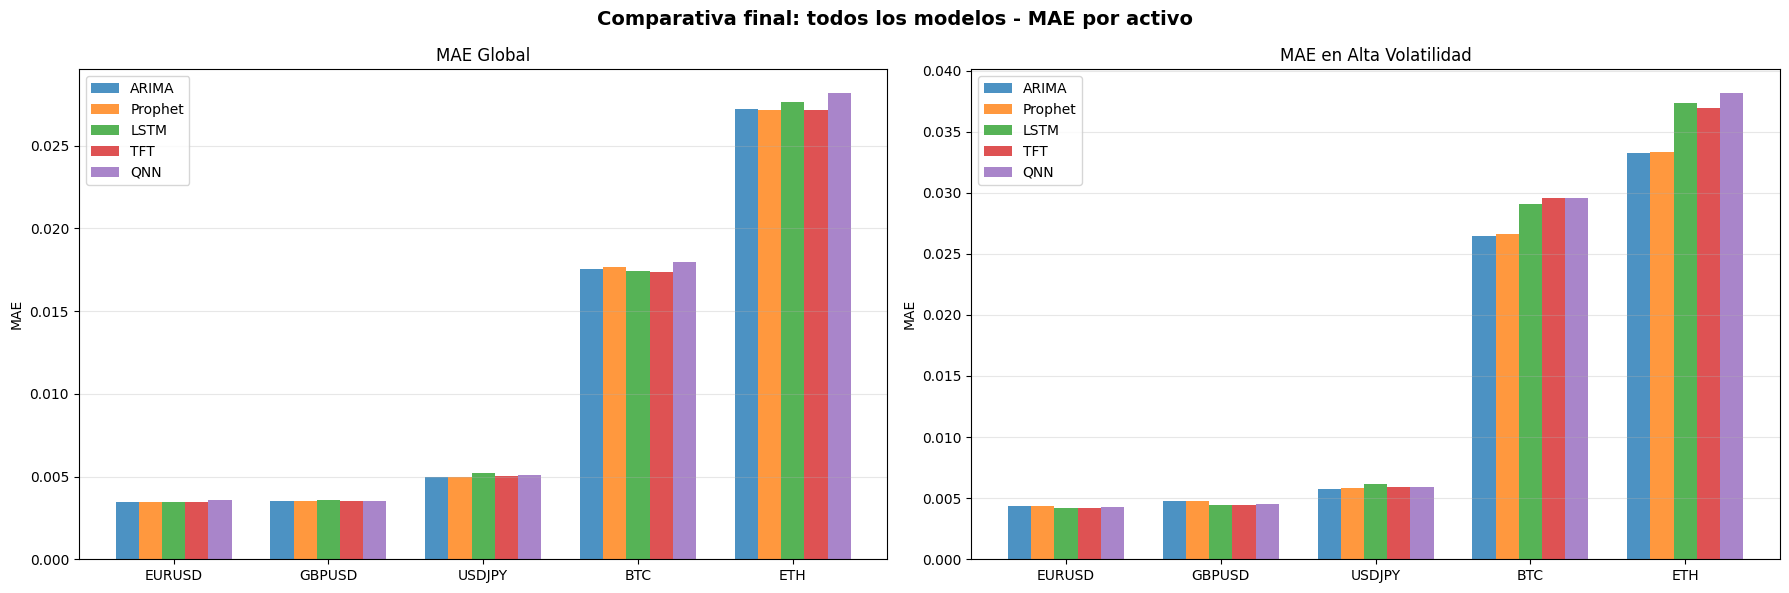

Gráfico guardado en results/07_comparativa_final_todos_modelos.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparativa final: todos los modelos - MAE por activo", fontsize=14, fontweight="bold")

activos_labels = comparativa_final["Activo"].values
x     = np.arange(len(activos_labels))
width = 0.15
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
modelos = ["ARIMA", "Prophet", "LSTM", "TFT", "QNN"]

# MAE Global
for i, (col, label) in enumerate(zip(modelos, modelos)):
    axes[0].bar(x + (i-2)*width, comparativa_final[col], width, label=label, color=colores[i], alpha=0.8)
axes[0].set_title("MAE Global")
axes[0].set_xticks(x)
axes[0].set_xticklabels(activos_labels)
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# MAE Alta Volatilidad
cols_alta = ["ARIMA_alta", "Prophet_alta", "LSTM_alta", "TFT_alta", "QNN_alta"]
for i, (col, label) in enumerate(zip(cols_alta, modelos)):
    axes[1].bar(x + (i-2)*width, comparativa_final[col], width, label=label, color=colores[i], alpha=0.8)
axes[1].set_title("MAE en Alta Volatilidad")
axes[1].set_xticks(x)
axes[1].set_xticklabels(activos_labels)
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_PATH / "07_comparativa_final_todos_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en results/07_comparativa_final_todos_modelos.png")

## Interpretación visual

El gráfico confirma la convergencia de todos los modelos en Forex — las cinco
barras son prácticamente indistinguibles. En cripto, la dispersión entre modelos
es mayor, especialmente en alta volatilidad (gráfico derecho), donde LSTM y QNN
muestran mayor error que los modelos clásicos y TFT en BTC y ETH.

El resultado más relevante académicamente es la ausencia de mejora clara del QNN sobre los modelos clásicos, lo que ilustra la brecha actual entre la computación cuántica simulada y la ventaja cuántica real.
